# SPY Oscillator Strategy — Fixed Version


*Filip / Strateva — April 2026*

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

## 1. Data

In [2]:
def fetch_data(start_date='2017-01-01', end_date='2024-12-31'):
    print("Downloading data...")
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    data = pd.DataFrame(index=spy.index)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)
    data['SPY'] = spy['Close']

    for ticker in ['XLK', 'XLY', 'XLI', 'XLP', 'XLU', 'XLV', '^VIX', '^VIX3M']:
        print(f"  Downloading {ticker}...")
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        data[ticker] = df['Close']

    data = data.dropna()
    print(f"  -> {len(data)} rows")
    return data

data = fetch_data()

  -> 2011 rows


## 2. Oscillator — Fixed Scaling (Z-Scored Components)

In [3]:
def rolling_zscore(series, window=63):
    """Z-score expanding (min 63 obs) to avoid look-ahead."""
    mu = series.expanding(min_periods=window).mean()
    sigma = series.expanding(min_periods=window).std()
    return (series - mu) / (sigma + 1e-10)


def calculate_oscillator(df):
    """
    Three components, each z-scored so they contribute equally:
      1. Trend: (EMA8 - EMA24) / EMA24
      2. Momentum: 21-day return of SPY
      3. Risk appetite: cyclical/defensive ratio - VIX term structure
    """
    # Component 1: Trend (EMA crossover normalized)
    ema8 = df['SPY'].ewm(span=8, adjust=False).mean()
    ema24 = df['SPY'].ewm(span=24, adjust=False).mean()
    trend_raw = (ema8 - ema24) / ema24

    # Component 2: Momentum
    momentum_raw = df['SPY'].pct_change(21)

    # Component 3: Risk appetite
    cyclical = df[['XLK', 'XLY', 'XLI']].mean(axis=1)
    defensive = df[['XLP', 'XLU', 'XLV']].mean(axis=1)
    cycl_def_raw = cyclical / defensive
    vix_ratio_raw = df['^VIX'] / df['^VIX3M']
    risk_appetite_raw = cycl_def_raw - vix_ratio_raw

    # Z-score each component (expanding, no look-ahead)
    trend_z = rolling_zscore(trend_raw)
    momentum_z = rolling_zscore(momentum_raw)
    risk_z = rolling_zscore(risk_appetite_raw)

    # Equal-weighted composite
    oscillator = (trend_z + momentum_z + risk_z) / 3.0

    # Signal MAs on the oscillator
    ma_fast = oscillator.ewm(span=5, adjust=False).mean()
    ma_slow = oscillator.ewm(span=21, adjust=False).mean()

    # Volatility bands
    vol = oscillator.rolling(21).std()
    upper_band = ma_slow + 2 * vol
    lower_band = ma_slow - 2 * vol

    # Buy signals: fast crosses above slow, OR fast bounces off lower band
    prev_fast = ma_fast.shift(1)
    prev_slow = ma_slow.shift(1)

    cross_up = (ma_fast > ma_slow) & (prev_fast <= prev_slow)
    bounce_up = (ma_fast > lower_band) & (prev_fast <= lower_band)
    buy_signals = (cross_up | bounce_up).astype(int)

    # Sell signals: fast crosses below slow, OR fast bounces off upper band
    cross_down = (ma_fast < ma_slow) & (prev_fast >= prev_slow)
    bounce_down = (ma_fast < upper_band) & (prev_fast >= upper_band)
    sell_signals = (cross_down | bounce_down).astype(int)

    # Filter signals too close together (min 10 days apart)
    min_days = 10
    for i in range(min_days, len(buy_signals)):
        if buy_signals.iloc[i] == 1:
            if buy_signals.iloc[i-min_days:i].sum() > 0:
                buy_signals.iloc[i] = 0
    for i in range(min_days, len(sell_signals)):
        if sell_signals.iloc[i] == 1:
            if sell_signals.iloc[i-min_days:i].sum() > 0:
                sell_signals.iloc[i] = 0

    results = pd.DataFrame({
        'price': df['SPY'],
        'oscillator': oscillator,
        'ma_fast': ma_fast,
        'ma_slow': ma_slow,
        'upper_band': upper_band,
        'lower_band': lower_band,
        'buy_signal': buy_signals,
        'sell_signal': sell_signals,
        'trend_z': trend_z,
        'momentum_z': momentum_z,
        'risk_z': risk_z,
    })
    return results

results = calculate_oscillator(data)
print(f"Buy signals:  {results['buy_signal'].sum()}")
print(f"Sell signals: {results['sell_signal'].sum()}")

Buy signals:  58
Sell signals: 55


## 3. Oscillator Visualization

C:\Users\User\AppData\Local\Temp\ipykernel_31884\2023752669.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


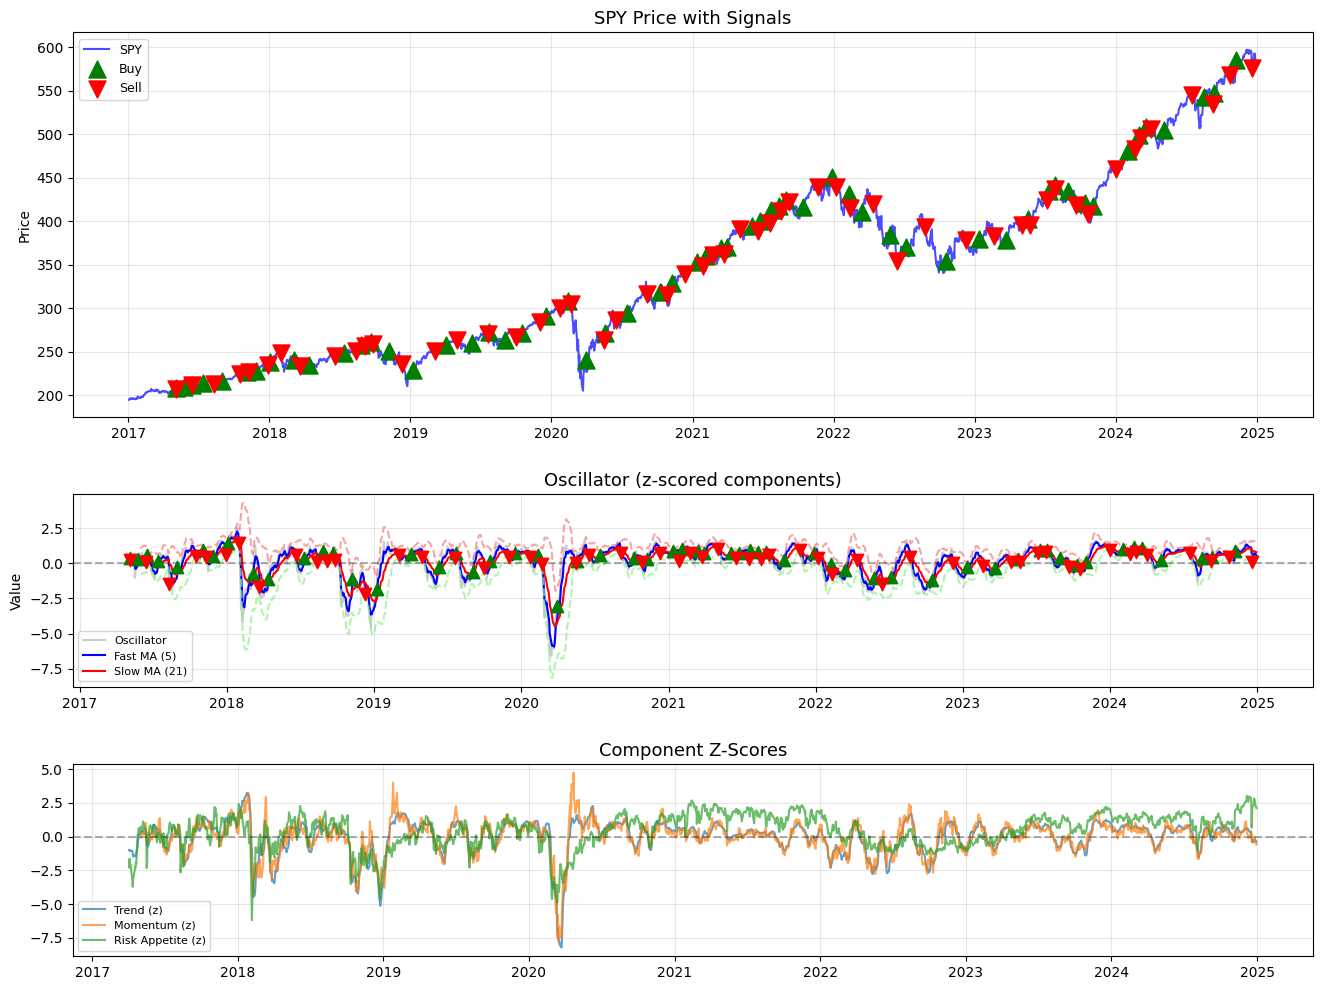

In [4]:
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.3)

# Price + signals
ax1 = fig.add_subplot(gs[0])
ax1.plot(results.index, results['price'], label='SPY', color='blue', alpha=0.7)
buys = results[results['buy_signal'] == 1].index
sells = results[results['sell_signal'] == 1].index
ax1.scatter(buys, results.loc[buys, 'price'], marker='^', color='green', s=150, label='Buy', zorder=5)
ax1.scatter(sells, results.loc[sells, 'price'], marker='v', color='red', s=150, label='Sell', zorder=5)
ax1.set_title('SPY Price with Signals', fontsize=13)
ax1.set_ylabel('Price')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Oscillator + MAs + bands
ax2 = fig.add_subplot(gs[1])
ax2.plot(results.index, results['oscillator'], label='Oscillator', color='gray', alpha=0.4)
ax2.plot(results.index, results['ma_fast'], label='Fast MA (5)', color='blue', linewidth=1.5)
ax2.plot(results.index, results['ma_slow'], label='Slow MA (21)', color='red', linewidth=1.5)
ax2.plot(results.index, results['upper_band'], color='lightcoral', linestyle='--', alpha=0.7)
ax2.plot(results.index, results['lower_band'], color='lightgreen', linestyle='--', alpha=0.7)
ax2.scatter(buys, results.loc[buys, 'oscillator'], marker='^', color='green', s=80, zorder=5)
ax2.scatter(sells, results.loc[sells, 'oscillator'], marker='v', color='red', s=80, zorder=5)
ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('Oscillator (z-scored components)', fontsize=13)
ax2.set_ylabel('Value')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Component contributions
ax3 = fig.add_subplot(gs[2])
ax3.plot(results.index, results['trend_z'], label='Trend (z)', alpha=0.7)
ax3.plot(results.index, results['momentum_z'], label='Momentum (z)', alpha=0.7)
ax3.plot(results.index, results['risk_z'], label='Risk Appetite (z)', alpha=0.7)
ax3.axhline(0, color='black', linestyle='--', alpha=0.3)
ax3.set_title('Component Z-Scores', fontsize=13)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Backtest 


In [9]:
def backtest_strategy(df, initial_capital=100000, cost_per_trade=0.0005):
    """
    Fixed backtest:
      - Signal at T -> position change at T+1 (no look-ahead)
      - Transaction costs: cost_per_trade applied on each entry/exit
    """
    daily_returns = df['price'].pct_change()
    n = len(df)

    position = 0  # 0 = cash, 1 = long
    strategy_returns = []
    equity = initial_capital
    equity_curve = [initial_capital]
    positions = []
    n_trades = 0

    for i in range(1, n):
        prev_pos = position
        if df['buy_signal'].iloc[i - 1] == 1 and position == 0:
            position = 1
            n_trades += 1
        elif df['sell_signal'].iloc[i - 1] == 1 and position == 1:
            position = 0
            n_trades += 1

        ret = daily_returns.iloc[i] if position == 1 else 0.0

        if position != prev_pos:
            ret -= cost_per_trade

        strategy_returns.append(ret)
        positions.append(position)
        equity *= (1 + ret)
        equity_curve.append(equity)

    strategy_returns = pd.Series(strategy_returns, index=df.index[1:])
    positions = pd.Series(positions, index=df.index[1:])
    equity_curve = pd.Series(equity_curve, index=df.index)

    bh_equity = initial_capital * (1 + daily_returns.fillna(0)).cumprod()
    bh_returns = daily_returns.fillna(0)

    return {
        'strategy_returns': strategy_returns,
        'bh_returns': bh_returns.iloc[1:],
        'strategy_equity': equity_curve,
        'bh_equity': bh_equity,
        'positions': positions,
        'n_trades': n_trades
    }

bt = backtest_strategy(results, cost_per_trade=0.0005)
print(f"Total trades: {bt['n_trades']}")

Total trades: 106


## 5. Performance Metrics

In [6]:
def calculate_performance_metrics(returns, risk_free_rate=0.0225):
    rf_daily = (1 + risk_free_rate) ** (1/252) - 1
    total_return = (1 + returns).prod() - 1
    years = len(returns) / 252
    annual_return = (1 + total_return) ** (1/years) - 1
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = np.sqrt(252) * (returns - rf_daily).mean() / returns.std() if returns.std() > 0 else 0

    cum = (1 + returns).cumprod()
    peak = cum.expanding().max()
    max_dd = (cum / peak - 1).min()

    neg = returns[returns < 0]
    downside_vol = neg.std() * np.sqrt(252) if len(neg) > 0 else np.nan
    sortino = (annual_return - risk_free_rate) / downside_vol if downside_vol and downside_vol > 0 else np.nan
    calmar = annual_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Total Return': total_return,
        'Annual Return': annual_return,
        'Annual Volatility': annual_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Max Drawdown': max_dd
    }

m_strat = calculate_performance_metrics(bt['strategy_returns'])
m_bh = calculate_performance_metrics(bt['bh_returns'])

print("=" * 50)
print("STRATEGY vs BUY & HOLD")
print("=" * 50)
for k in m_strat:
    fmt = '.2%' if 'Return' in k or 'Vol' in k or 'Drawdown' in k else '.2f'
    print(f"{k:20s}  Strat: {m_strat[k]:{fmt}}   B&H: {m_bh[k]:{fmt}}")

STRATEGY vs BUY & HOLD
Total Return          Strat: 91.13%   B&H: 198.15%
Annual Return         Strat: 8.46%   B&H: 14.68%
Annual Volatility     Strat: 10.47%   B&H: 18.36%
Sharpe Ratio          Strat: 0.62   B&H: 0.72
Sortino Ratio         Strat: 0.58   B&H: 0.80
Calmar Ratio          Strat: 0.57   B&H: 0.44
Max Drawdown          Strat: -14.82%   B&H: -33.72%


## 6. Backtest Visualization

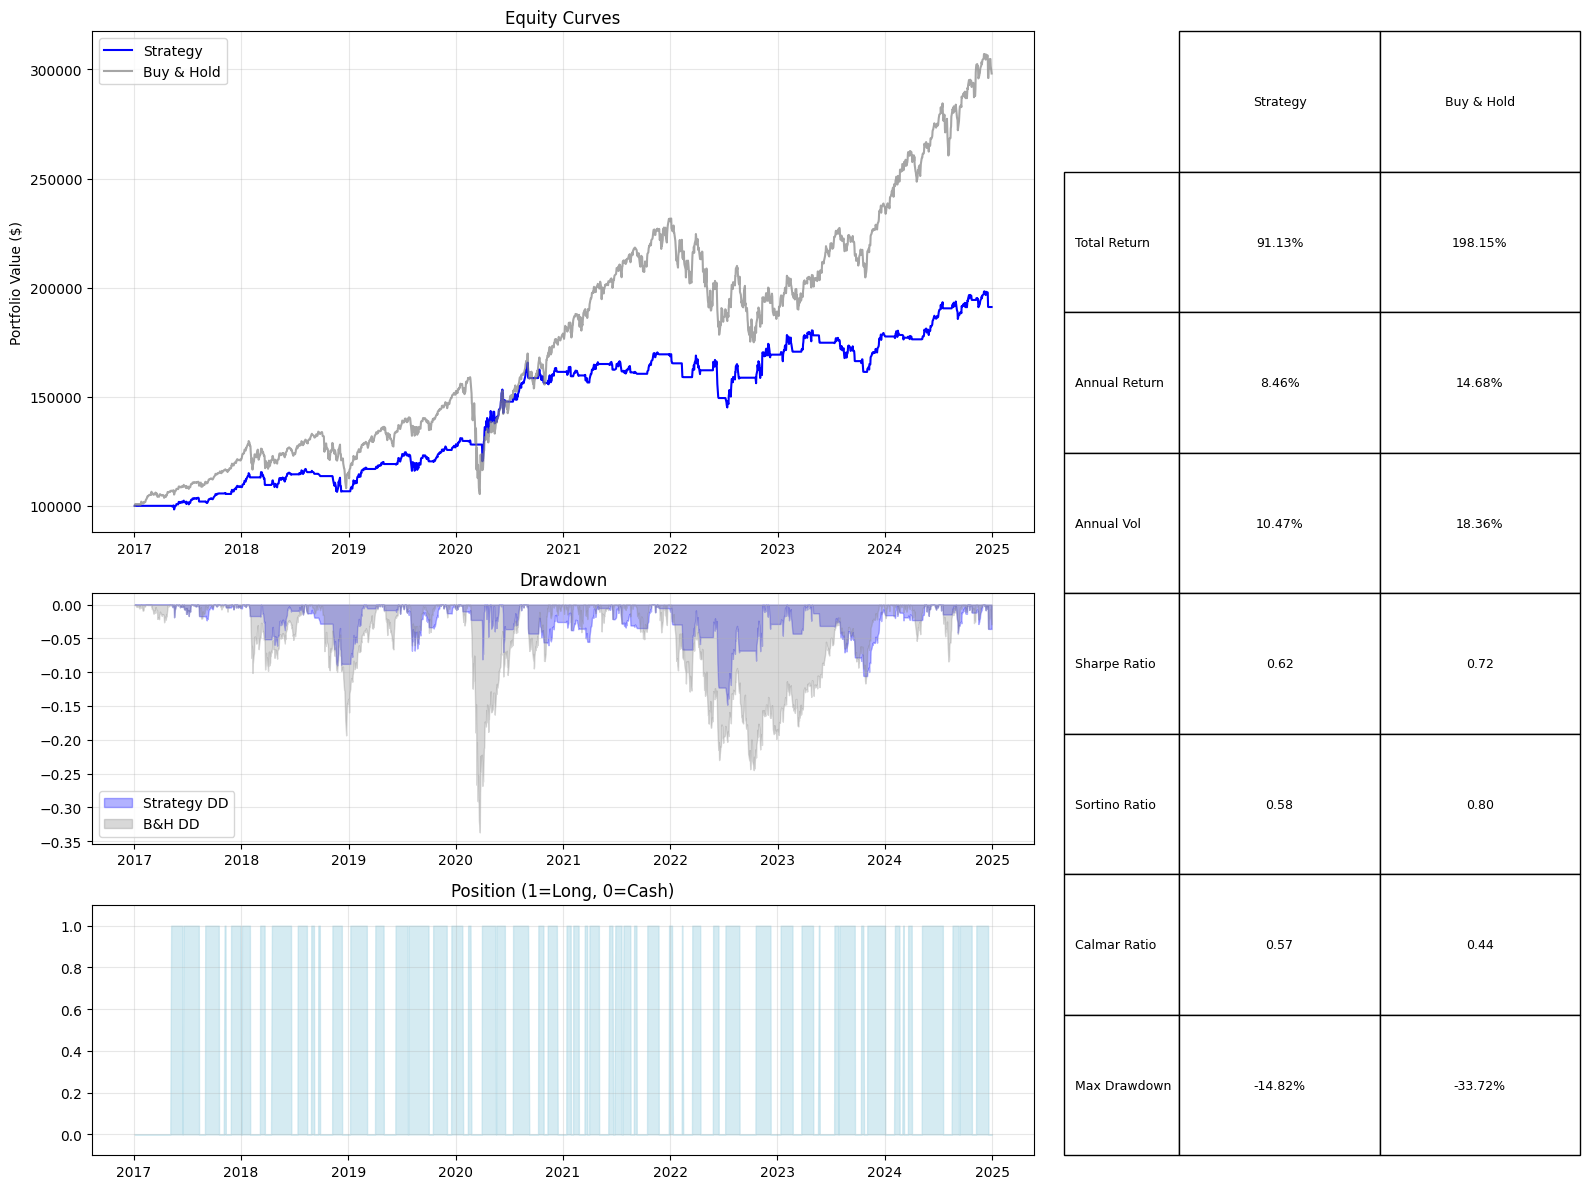

In [7]:
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 2, height_ratios=[2, 1, 1], width_ratios=[2, 1])

# Equity curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(bt['strategy_equity'], label='Strategy', color='blue', linewidth=1.5)
ax1.plot(bt['bh_equity'], label='Buy & Hold', color='gray', linewidth=1.5, alpha=0.7)
ax1.set_title('Equity Curves')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
s_dd = bt['strategy_equity'] / bt['strategy_equity'].expanding().max() - 1
b_dd = bt['bh_equity'] / bt['bh_equity'].expanding().max() - 1
ax2.fill_between(s_dd.index, s_dd, 0, color='blue', alpha=0.3, label='Strategy DD')
ax2.fill_between(b_dd.index, b_dd, 0, color='gray', alpha=0.3, label='B&H DD')
ax2.set_title('Drawdown')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Position
ax3 = fig.add_subplot(gs[2, 0])
ax3.fill_between(bt['positions'].index, bt['positions'], color='lightblue', alpha=0.5)
ax3.set_title('Position (1=Long, 0=Cash)')
ax3.set_ylim(-0.1, 1.1)
ax3.grid(True, alpha=0.3)

# Metrics table
ax4 = fig.add_subplot(gs[:, 1])
rows = ['Total Return', 'Annual Return', 'Annual Vol', 'Sharpe Ratio',
        'Sortino Ratio', 'Calmar Ratio', 'Max Drawdown']
strat_vals = [
    f"{m_strat['Total Return']:.2%}",
    f"{m_strat['Annual Return']:.2%}",
    f"{m_strat['Annual Volatility']:.2%}",
    f"{m_strat['Sharpe Ratio']:.2f}",
    f"{m_strat['Sortino Ratio']:.2f}",
    f"{m_strat['Calmar Ratio']:.2f}",
    f"{m_strat['Max Drawdown']:.2%}"
]
bh_vals = [
    f"{m_bh['Total Return']:.2%}",
    f"{m_bh['Annual Return']:.2%}",
    f"{m_bh['Annual Volatility']:.2%}",
    f"{m_bh['Sharpe Ratio']:.2f}",
    f"{m_bh['Sortino Ratio']:.2f}",
    f"{m_bh['Calmar Ratio']:.2f}",
    f"{m_bh['Max Drawdown']:.2%}"
]
ax4.axis('off')
table = ax4.table(
    cellText=list(zip(strat_vals, bh_vals)),
    rowLabels=rows, colLabels=['Strategy', 'Buy & Hold'],
    cellLoc='center', loc='center', bbox=[0.15, 0, 0.85, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()